# 03 - EDA Facturacion Y Churn

## Hipotesis iniciales

1. Impagos y retrasos recientes anticipan mayor probabilidad de churn en el mes siguiente.
2. Cambios en consumo, importe mensual o descuento pueden actuar como senales tempranas de desenganche, stress economico o cambio de uso.
3. La facturacion debe analizarse con target futuro `churn_t_plus_1`, no con churn del mismo mes, para evitar leakage temporal.
4. Las relaciones pueden ser debiles de forma individual, pero utiles cuando se agregan como lags y ventanas moviles.
5. El comportamiento economico puede variar por plan, por lo que conviene contrastar impago, retraso y churn tambien por segmentos.

## Que se va a contrastar

- Distribucion mensual del churn futuro y metricas economicas.
- Tasas de churn por impago, retraso de pago y tipo de plan.
- Correlaciones entre variables economicas y `churn_t_plus_1`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

fact = pd.read_csv(PROCESSED / 'facturacion_mensual_clean.csv', parse_dates=['fecha'])
churn = pd.read_csv(PROCESSED / 'churn_target_clean.csv', parse_dates=['fecha'])
churn = churn.sort_values(['cliente_id', 'fecha'])
churn['churn_t_plus_1'] = churn.groupby('cliente_id')['churn'].shift(-1)
base = churn.dropna(subset=['churn_t_plus_1'])[['cliente_id', 'fecha', 'churn_t_plus_1']]
df = fact.merge(base, on=['cliente_id', 'fecha'], how='inner')
df['churn_t_plus_1'] = df['churn_t_plus_1'].astype(int)


In [2]:
display(df.head())
display(df['churn_t_plus_1'].value_counts(normalize=True).mul(100).round(3))


,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag,tipo_plan_was_missing,importe_total_was_missing,churn_t_plus_1
0,C000001,2023-01-01,Z26,Prepago,2,43.650,6.980,0.000,50.620,0,0,0.000,0.000,0,0,0,0
1,C000001,2023-02-01,Z26,Prepago,2,43.650,10.330,0.000,53.980,0,0,0.481,0.410,0,0,0,0
2,C000001,2023-03-01,Z26,Prepago,2,43.650,10.870,0.000,54.520,0,0,0.052,0.422,0,0,0,0
3,C000001,2023-04-01,Z26,Prepago,2,43.650,6.820,0.000,50.470,0,0,-0.372,0.430,0,0,0,0
4,C000001,2023-05-01,Z26,Prepago,2,43.650,13.260,0.000,56.900,0,0,0.943,0.449,0,0,0,0


churn_t_plus_1
0   99.365
1    0.635
Name: proportion, dtype: float64

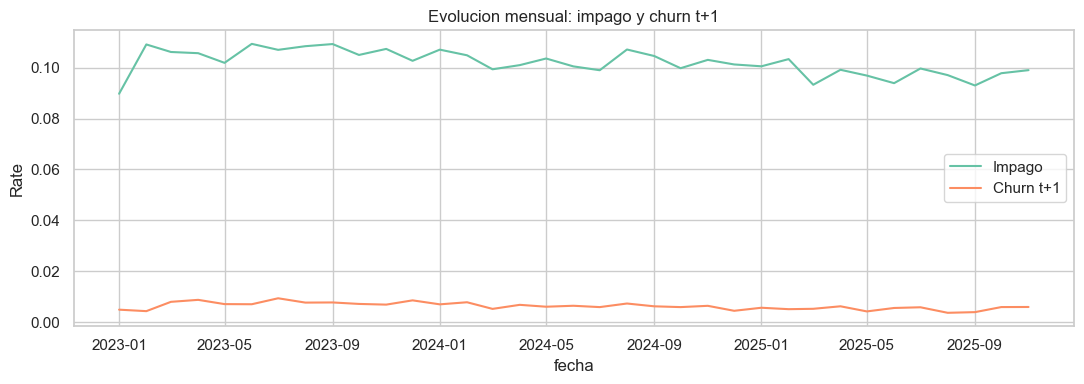

In [3]:
monthly = df.groupby('fecha', as_index=False).agg(
    impago_rate=('impago_flag', 'mean'),
    churn_t1_rate=('churn_t_plus_1', 'mean'),
    retraso_medio=('dias_retraso_pago', 'mean')
)
fig, ax1 = plt.subplots(figsize=(11, 4))
sns.lineplot(data=monthly, x='fecha', y='impago_rate', ax=ax1, label='Impago')
sns.lineplot(data=monthly, x='fecha', y='churn_t1_rate', ax=ax1, label='Churn t+1')
plt.title('Evolucion mensual: impago y churn t+1')
plt.ylabel('Rate')
plt.tight_layout()
plt.show()


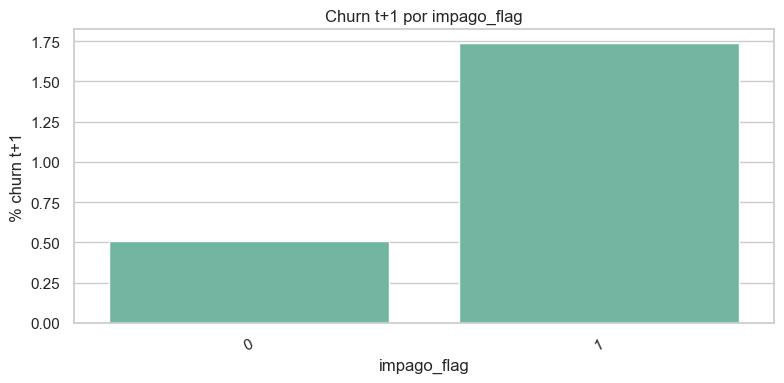

,impago_flag,n,churn_rate
1,1,31851,1.736
0,0,280136,0.510


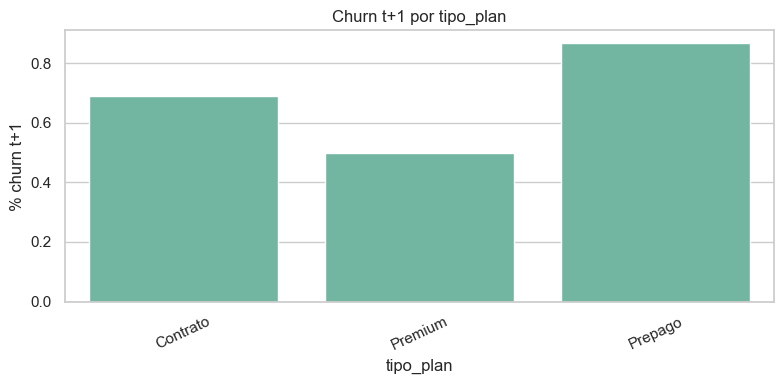

,tipo_plan,n,churn_rate
2,Prepago,80100,0.866
0,Contrato,69815,0.690
1,Premium,162072,0.497


In [4]:
for col in ['impago_flag', 'tipo_plan']:
    rates = df.groupby(col)['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
    rates['churn_rate'] *= 100
    plt.figure(figsize=(8, 4))
    sns.barplot(data=rates, x=col, y='churn_rate')
    plt.title(f'Churn t+1 por {col}')
    plt.ylabel('% churn t+1')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
    display(rates.sort_values('churn_rate', ascending=False))


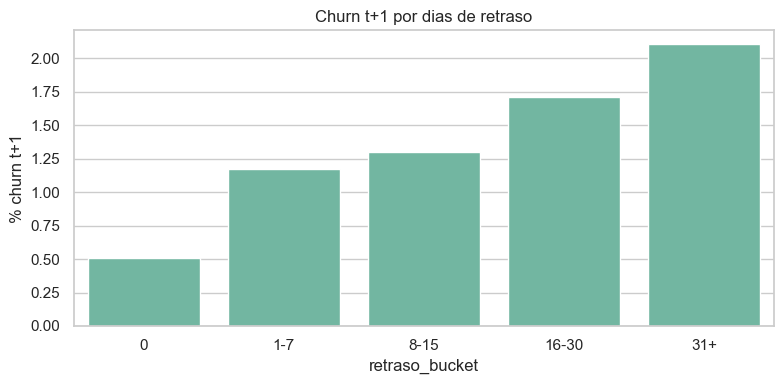

In [5]:
df['retraso_bucket'] = pd.cut(df['dias_retraso_pago'], bins=[-1, 0, 7, 15, 30, 90], labels=['0', '1-7', '8-15', '16-30', '31+'])
rates = df.groupby('retraso_bucket')['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
rates['churn_rate'] *= 100
plt.figure(figsize=(8, 4))
sns.barplot(data=rates, x='retraso_bucket', y='churn_rate')
plt.title('Churn t+1 por dias de retraso')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()


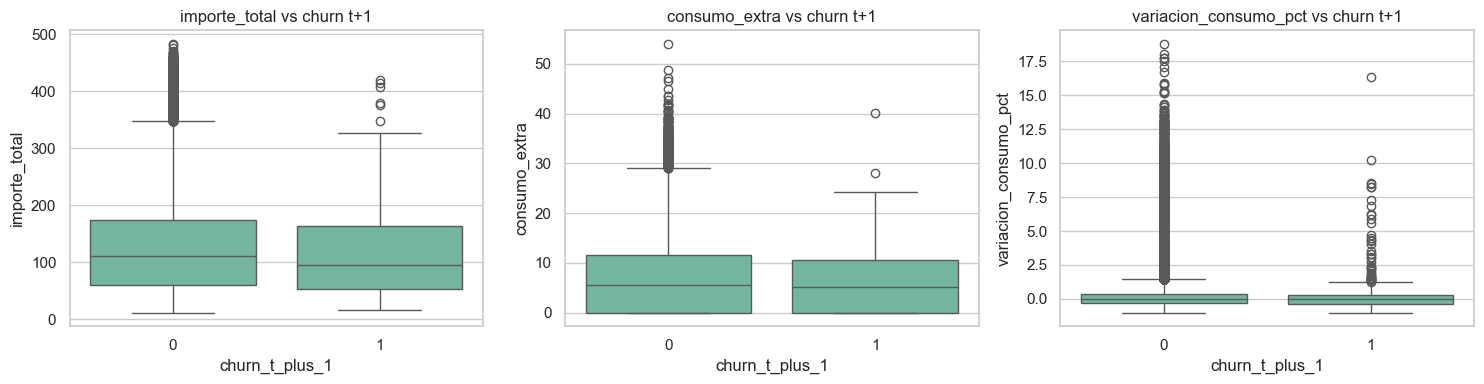

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['importe_total', 'consumo_extra', 'variacion_consumo_pct']):
    sns.boxplot(data=df.sample(min(len(df), 50000), random_state=42), x='churn_t_plus_1', y=col, ax=ax)
    ax.set_title(f'{col} vs churn t+1')
plt.tight_layout()
plt.show()


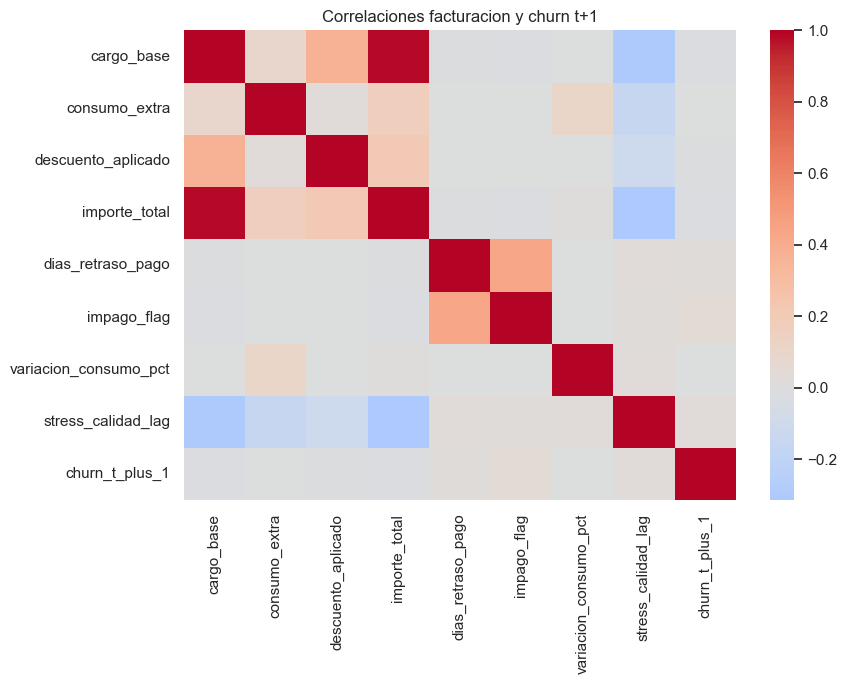

churn_t_plus_1           1.000
impago_flag              0.047
stress_calidad_lag       0.029
dias_retraso_pago        0.021
variacion_consumo_pct   -0.004
consumo_extra           -0.007
descuento_aplicado      -0.008
importe_total           -0.013
cargo_base              -0.013
Name: churn_t_plus_1, dtype: float64

In [7]:
corr_cols = ['cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total', 'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct', 'stress_calidad_lag', 'churn_t_plus_1']
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlaciones facturacion y churn t+1')
plt.tight_layout()
plt.show()
display(corr['churn_t_plus_1'].sort_values(ascending=False))


## Conclusiones finales

- El churn mensual futuro es muy minoritario: en la muestra analizada `churn_t_plus_1` ronda el 0.635%, lo que anticipa un problema de clases desbalanceadas.
- El impago es una de las senales economicas mas claras: los registros con `impago_flag=1` muestran una tasa de churn cercana al 1.736%, frente a aproximadamente 0.510% cuando no hay impago.
- Los dias de retraso tambien aportan informacion, aunque su relacion debe tratarse con cautela y preferiblemente mediante buckets, lags y rolling windows.
- Las correlaciones lineales individuales son bajas, pero `impago_flag`, retrasos y variables de stress aparecen entre las asociaciones mas relevantes con churn futuro.
- La facturacion es especialmente valiosa porque se actualiza mensualmente y permite construir senales temporales accionables sin mirar informacion posterior.

## Decisiones para feature engineering

- Crear lags `t-1`, `t-2`, `t-3` para variables economicas.
- Crear rolling de 3 meses para importes, consumo, impago y retrasos.
- Mantener buckets de retraso de pago para capturar relaciones no lineales.
- Mantener flags de imputacion de facturacion.
- Asegurar que ninguna variable de facturacion posterior a `t` entre en el entrenamiento.
